# PCS Metrics (patent→paper) — Validation & Visualization

Face-validity checks for the PCS outputs (how often **US patents cite each paper**), rendered inline:
coverage, citation distributions, windowed monotonicity, accrual by publication year (patent citations
are slow), examiner vs non-examiner share, windowed-vs-total, and hit-percentile distribution.

## Inputs
```
notebook/pcs/output/pcs_citation.parquet        # C_{3,5,10,all} + C_examiner/non_examiner_{w} + C_total(+split)
notebook/pcs/output/pcs_hit_probability.parquet # FoS, year, pctl_{c3,c5,c10,call}
```

In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110; plt.rcParams['axes.grid'] = True; plt.rcParams['grid.alpha'] = 0.3
for _ in range(6):
    if os.path.isdir(os.path.join('notebook', 'pcs', 'output')): break
    os.chdir('..')
ROOT = os.getcwd(); print('ROOT:', ROOT)
POUT = os.path.join(ROOT, 'notebook', 'pcs', 'output')

ROOT: C:\Users\jdwoo\OneDrive\Desktop\Research\Science of Science


## 1. Load pcs_citation + pcs_hit (merge on paper_id)

In [2]:
%%time
cit = pd.read_parquet(os.path.join(POUT, 'pcs_citation.parquet'))
hit = pd.read_parquet(os.path.join(POUT, 'pcs_hit_probability.parquet'))
df = cit.merge(hit, on='paper_id', how='left')
print('rows:', {'cit': len(cit), 'hit': len(hit), 'merged': len(df)}); print('cols:', list(df.columns))
df.head(3)

rows: {'cit': 5106527, 'hit': 4940946, 'merged': 5106527}
cols: ['paper_id', 'C_3', 'C_5', 'C_10', 'C_all', 'C_examiner_3', 'C_non_examiner_3', 'C_examiner_5', 'C_non_examiner_5', 'C_examiner_10', 'C_non_examiner_10', 'C_examiner_all', 'C_non_examiner_all', 'C_total', 'C_examiner_total', 'C_non_examiner_total', 'FoS', 'year', 'pctl_c3', 'pctl_c5', 'pctl_c10', 'pctl_call']
CPU times: total: 8.28 s
Wall time: 7.15 s


,paper_id,C_3,C_5,C_10,C_all,C_examiner_3,C_non_examiner_3,C_examiner_5,C_non_examiner_5,C_examiner_10,...,C_non_examiner_all,C_total,C_examiner_total,C_non_examiner_total,FoS,year,pctl_c3,pctl_c5,pctl_c10,pctl_call
0,W979,0,0,1,1,0,0,0,0,0,...,1,1,0,1,Physics,2006.0,0.000225,0.000225,0.332434,0.018881
1,W1552,0,0,0,6,0,0,0,0,0,...,6,6,0,6,Materials science,2009.0,0.000044,0.000044,0.000044,0.845426
2,W3066,0,0,1,10,0,0,0,0,0,...,10,10,0,10,Medicine,1999.0,0.000053,0.000053,0.558501,0.836634


## 2. Coverage + citation-count distributions (log, cited-only)

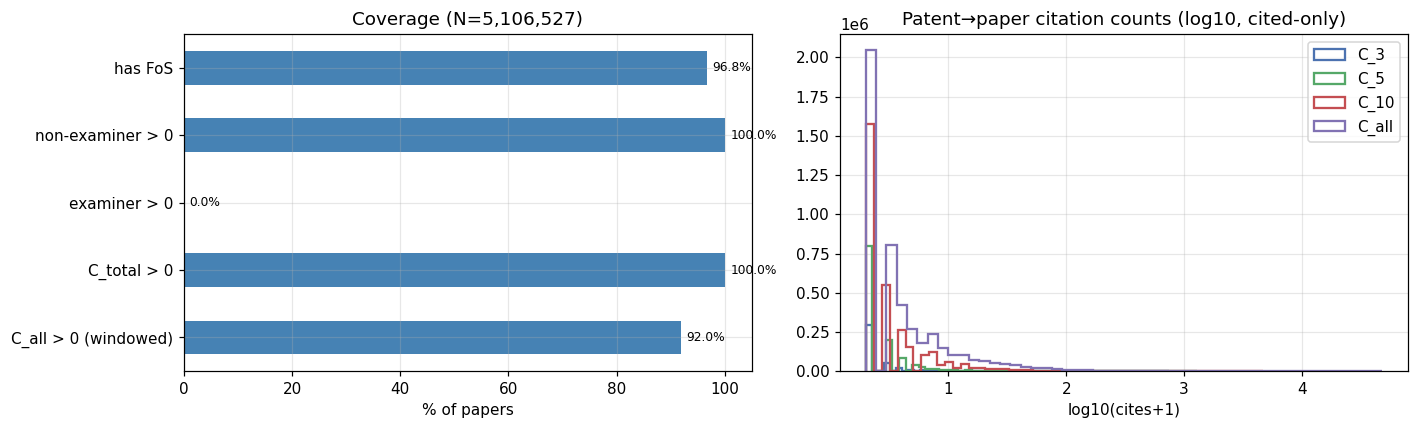

means: {'C_3': np.float64(0.138), 'C_5': np.float64(0.536), 'C_10': np.float64(2.167), 'C_all': np.float64(6.285), 'C_total': np.float64(6.82)}


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
cov = pd.Series({
    'C_all > 0 (windowed)': (df['C_all'] > 0).mean() * 100,
    'C_total > 0': (df['C_total'] > 0).mean() * 100,
    'examiner > 0': (df['C_examiner_total'] > 0).mean() * 100,
    'non-examiner > 0': (df['C_non_examiner_total'] > 0).mean() * 100,
    'has FoS': df['FoS'].notna().mean() * 100,
})
cov.plot.barh(ax=ax[0], color='steelblue'); ax[0].set_xlabel('% of papers'); ax[0].set_title(f'Coverage (N={len(df):,})')
for i, v in enumerate(cov.values): ax[0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)
for c, col in zip(['C_3', 'C_5', 'C_10', 'C_all'], ['#4c72b0', '#55a868', '#c44e52', '#8172b3']):
    v = df[c][df[c] > 0]
    ax[1].hist(np.log10(v + 1), bins=50, histtype='step', label=c, color=col, linewidth=1.5)
ax[1].set_title('Patent→paper citation counts (log10, cited-only)'); ax[1].set_xlabel('log10(cites+1)'); ax[1].legend()
plt.tight_layout(); plt.show()
print('means:', {c: round(df[c].mean(), 3) for c in ['C_3', 'C_5', 'C_10', 'C_all', 'C_total']})

## 3. Windowed monotonicity + windowed vs total

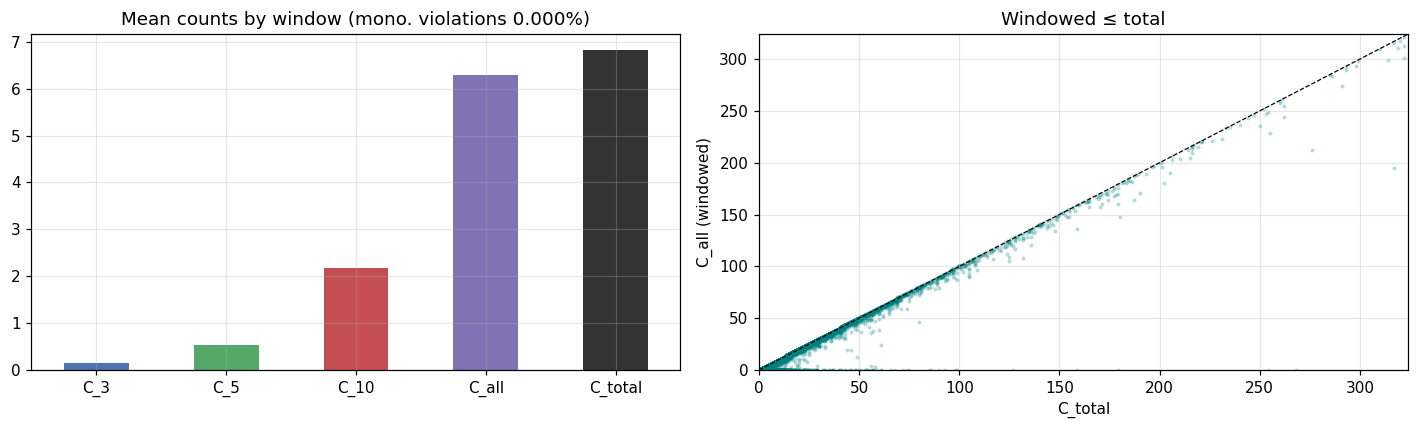

C_3<=C_5<=C_10<=C_all violations: 0.0000%  |  C_all>C_total rows: 0.000%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
viol = ((df['C_3'] > df['C_5']) | (df['C_5'] > df['C_10']) | (df['C_10'] > df['C_all'])).mean() * 100
df[['C_3', 'C_5', 'C_10', 'C_all', 'C_total']].mean().plot.bar(
    ax=ax[0], color=['#4c72b0', '#55a868', '#c44e52', '#8172b3', '#333333'])
ax[0].set_title(f'Mean counts by window (mono. violations {viol:.3f}%)'); plt.setp(ax[0].get_xticklabels(), rotation=0)
# windowed C_all should be <= C_total (some citing patents lack a matched grant year)
ax[1].scatter(df['C_total'].sample(min(50000, len(df)), random_state=0),
              df.loc[df['C_total'].sample(min(50000, len(df)), random_state=0).index, 'C_all'],
              s=3, alpha=0.2, color='teal')
lim = np.log1p(df['C_total'].quantile(0.999))
ax[1].plot([0, df['C_total'].quantile(0.999)], [0, df['C_total'].quantile(0.999)], 'k--', lw=0.8)
ax[1].set_xlabel('C_total'); ax[1].set_ylabel('C_all (windowed)'); ax[1].set_title('Windowed ≤ total')
ax[1].set_xlim(0, df['C_total'].quantile(0.999)); ax[1].set_ylim(0, df['C_total'].quantile(0.999))
plt.tight_layout(); plt.show()
print(f'C_3<=C_5<=C_10<=C_all violations: {viol:.4f}%  |  C_all>C_total rows: {(df.C_all>df.C_total).mean()*100:.3f}%')

## 4. Citation accrual by publication year + examiner/non-examiner share

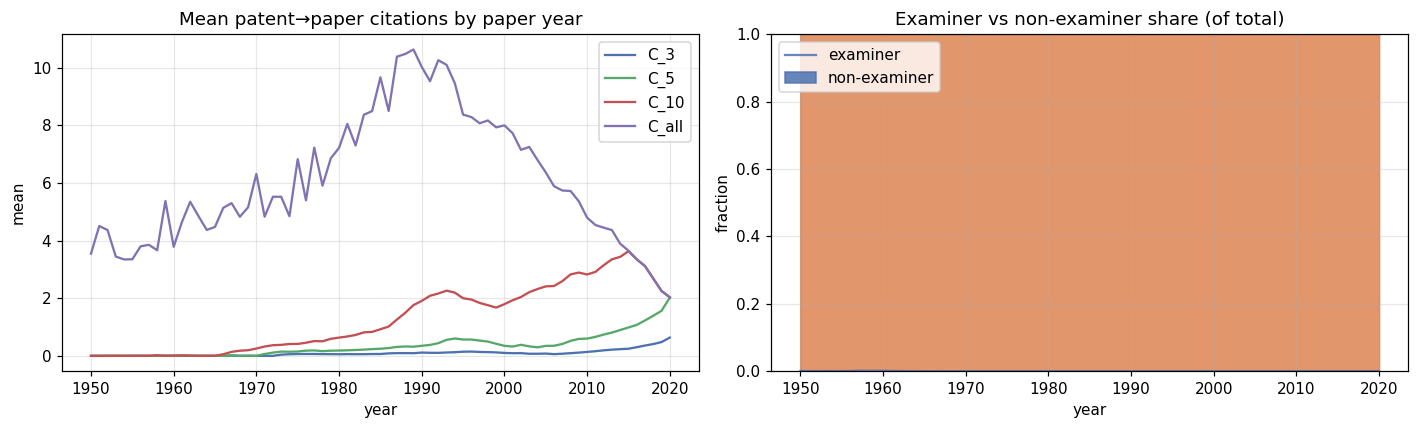

overall examiner share of total: 0.0%


In [5]:
d = df[df['year'].between(1950, 2020)]
g = d.groupby('year')
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['C_3', 'C_5', 'C_10', 'C_all'], ['#4c72b0', '#55a868', '#c44e52', '#8172b3']):
    g[c].mean().plot(ax=ax[0], label=c, color=col)
ax[0].set_title('Mean patent→paper citations by paper year'); ax[0].set_ylabel('mean'); ax[0].legend()
share = g[['C_examiner_total', 'C_non_examiner_total']].sum()
frac = share.div(share.sum(axis=1), axis=0)
frac.plot.area(ax=ax[1], color=['#4c72b0', '#dd8452'], alpha=0.85)
ax[1].set_title('Examiner vs non-examiner share (of total)'); ax[1].set_ylabel('fraction'); ax[1].set_ylim(0, 1)
ax[1].legend(['examiner', 'non-examiner'], loc='upper left')
plt.tight_layout(); plt.show()
print('overall examiner share of total: '
      f'{df.C_examiner_total.sum()/(df.C_examiner_total.sum()+df.C_non_examiner_total.sum())*100:.1f}%')

## 5. Hit percentile distribution + mean pctl by top fields

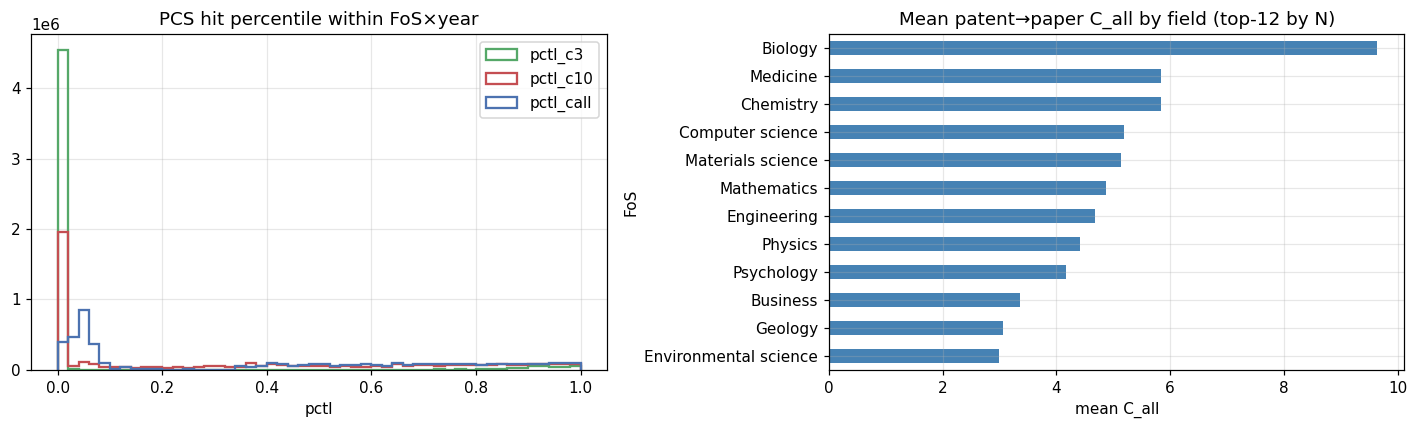

done — all PCS validation figures rendered inline.


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for c, col in zip(['pctl_c3', 'pctl_c10', 'pctl_call'], ['#55a868', '#c44e52', '#4c72b0']):
    ax[0].hist(df[c].dropna(), bins=50, histtype='step', label=c, color=col, linewidth=1.5)
ax[0].set_title('PCS hit percentile within FoS×year'); ax[0].set_xlabel('pctl'); ax[0].legend()
top = df['FoS'].value_counts().head(12).index
fos = df[df['FoS'].isin(top)].groupby('FoS')['C_all'].mean().sort_values()
fos.plot.barh(ax=ax[1], color='steelblue'); ax[1].set_title('Mean patent→paper C_all by field (top-12 by N)')
ax[1].set_xlabel('mean C_all')
plt.tight_layout(); plt.show()
print('done — all PCS validation figures rendered inline.')